# GSS with Zero Gradient Guidance
## (Experiment B)
This experiment is a controlled diagnostic of the end-to-end GGSS-R implementation, focusing specifically on the coupling between the authors' GSS sampling procedure and the gradient-guidance mechanism. The setup is motivated by findings from our previous diagnoses. In the unconditional test, the isolated diffusion model successfully denoised Gaussian noise over 1000 DDIM timesteps to generate samples on the natural image manifold, ruling out the base model as the cause of failure. However, in the full GGSS-R reproduction test, passing the victim model's leaked gradient at the authors' guidance rate \(m_r=0.2\) produced a failed reconstruction that aligned neither with the expected face domain nor the target image.

These results leave two distinct hypotheses to test:
* The gradient-guidance implementation or its coupling with the diffusion sampler is incorrect.
* The leaked gradient simply lacks enough identifiable information about the target image for the guidance mechanism to recover it.

This experiment tests the first hypothesis. By executing the full GGSS-R implementation end-to-end with guidance coefficient set to,

$$
m_r=0.
$$

we disable the gradient-guidance contribution while keeping the rest of the GGSS-R pipeline, including its GSS conditioning mechanism, fully active. This differs from the previous unconditional test, as the image is now generated directly through the GGSS-R code path.

The central question is: when the gradient-guidance term is neutralized, does the authors' GGSS-R implementation execute correctly? If the behavior is correct, i.e., generated images are on the natural manifold, then the reconstruction failure observed at \(m_r=0.2\) is likely to be caused by a lack of indetifiability in the leaked gradient. Conversely, if it behaves incorrectly, then the failure is attributed to an implementation error.

The notebook uses a fresh Experiment-B directory and a fresh checkout of the authors' code. The small code patches later in the notebook are restricted to output handling only. The underlying GSS calculation and the GGSS-R sampling logic are intentionally left as is.

# CELL 0 - Bootstrap: create an isolated workspace

This cell initializes a completely separate directory structure for this experiment.
Four directories are created:

- `repo/` for the fresh copy of the authors' repository,
- `input/` for copied checkpoints and the target image,
- `output/` for reconstruction results,
- `logs/` for the full experiment log.

The separation is important for reproducibility. This experiment should not silently modify files inside the earlier experiment directories.

In [ ]:
# ============================================================
# EXPERIMENT B
# GGSS-R / GSS with guidance_scale = 0
#
# CELL 0 — Bootstrap
# ============================================================

from google.colab import drive
from pathlib import Path
import os
import sys

drive.mount("/content/drive")

# ------------------------------------------------------------
# New separate experiment directory
# ------------------------------------------------------------

EXPERIMENT_ROOT = Path(
    "/content/drive/MyDrive/"
    "GGSS_R_experiment_B_GSS_zero_guidance"
).resolve()

REPO_ROOT = EXPERIMENT_ROOT / "repo"
INPUT_ROOT = EXPERIMENT_ROOT / "input"
OUTPUT_ROOT = EXPERIMENT_ROOT / "output"
LOG_ROOT = EXPERIMENT_ROOT / "logs"

for path in [
    REPO_ROOT,
    INPUT_ROOT,
    OUTPUT_ROOT,
    LOG_ROOT,
]:
    path.mkdir(
        parents=True,
        exist_ok=True,
    )

print("=" * 72)
print("EXPERIMENT B — GSS WITH ZERO GUIDANCE")
print("=" * 72)
print()
print("Experiment root :", EXPERIMENT_ROOT)
print("Repository      :", REPO_ROOT)
print("Input           :", INPUT_ROOT)
print("Output          :", OUTPUT_ROOT)
print("Logs            :", LOG_ROOT)

Mounted at /content/drive
EXPERIMENT B — GSS WITH ZERO GUIDANCE

Experiment root : /content/drive/MyDrive/GGSS_R_experiment_B_GSS_zero_guidance
Repository      : /content/drive/MyDrive/GGSS_R_experiment_B_GSS_zero_guidance/repo
Input           : /content/drive/MyDrive/GGSS_R_experiment_B_GSS_zero_guidance/input
Output          : /content/drive/MyDrive/GGSS_R_experiment_B_GSS_zero_guidance/output
Logs            : /content/drive/MyDrive/GGSS_R_experiment_B_GSS_zero_guidance/logs


### Result
The experiment's workspace is created under a new root, with separate locations for repo, copied inputs, outputs, and logs. 

# CELL 1 - Existing experiment inputs: identify the fixed reconstruction inputs

This cell locates the three inputs that the experiment is supposed to inherit from the earlier unperturbed reproduction:

1. the official FFHQ diffusion checkpoint `ffhq_10m.pt`,
2. the single-epoch-trained victim-model checkpoint `MLP_1.pth`,
3. the CelebA target image `target_0000.png`.

The paths are treated as read-only sources. The assertions make the notebook stop if any required input is missing.

The purpose is to keep the ablation controlled. Experiment B should change the guidance setting, not the trained diffusion model, victim model, or target. Verifying these files before copying them prevents an accidental change in the experimental inputs from being mistaken for an effect of removing gradient guidance.

In [ ]:
# ============================================================
# CELL 1 — Existing experiment inputs
# ============================================================

EXISTING_ROOT = Path(
    "/content/drive/MyDrive/"
    "GGSS_R_unperturbed_reproduction"
).resolve()

EXISTING_DIFFUSION_CHECKPOINT = (
    EXISTING_ROOT
    / "dps-checkpoint"
    / "ffhq_10m.pt"
)

EXISTING_VICTIM_CHECKPOINT = (
    EXISTING_ROOT
    / "model_state"
    / "MLP_1.pth"
)

EXISTING_TARGET = (
    EXISTING_ROOT
    / "data"
    / "samples"
    / "celeba_target"
    / "target_0000.png"
)

print("=" * 72)
print("EXISTING INPUTS — READ ONLY")
print("=" * 72)

inputs = {
    "FFHQ diffusion checkpoint":
        EXISTING_DIFFUSION_CHECKPOINT,

    "Victim MLP checkpoint":
        EXISTING_VICTIM_CHECKPOINT,

    "CelebA target":
        EXISTING_TARGET,
}

for name, path in inputs.items():

    print(
        f"{'✓' if path.is_file() else '✗'} "
        f"{name}"
    )

    print(
        "  ",
        path,
    )

    assert path.is_file(), (
        f"Required existing input is missing:\n{path}"
    )

print()
print("✓ All three required inputs are present.")
print()
print("IMPORTANT:")
print("Experiment B will COPY these files.")
print("It will never modify them.")

EXISTING INPUTS — READ ONLY
✓ FFHQ diffusion checkpoint
   /content/drive/MyDrive/GGSS_R_unperturbed_reproduction/dps-checkpoint/ffhq_10m.pt
✓ Victim MLP checkpoint
   /content/drive/MyDrive/GGSS_R_unperturbed_reproduction/model_state/MLP_1.pth
✓ CelebA target
   /content/drive/MyDrive/GGSS_R_unperturbed_reproduction/data/samples/celeba_target/target_0000.png

✓ All three required inputs are present.

IMPORTANT:
Experiment B will COPY these files.
It will never modify them.


### Result

All three required fixed inputs are present: the FFHQ diffusion checkpoint, the MLP victim checkpoint, and the CelebA target image.

# CELL 2 - Fresh authors' repository: pin the exact implementation

This cell clones the authors' GitHub repo into the this experiment's directory and checks out the exact commit used for the reproduction setup.

If an incomplete repository already exists, it is removed first so that the experiment starts from a clean checkout.

The final 'git rev-parse HEAD' check confirms that the repository is actually at the requested commit. Pinning the commit matters here because the ablation is only meaningful if the underlying implementation is held fixed. Otherwise, a later repository change could silently alter the result.

In [ ]:
# ============================================================
# CELL 2 — Fresh authors' repository
# ============================================================

import subprocess
import shutil

AUTHOR_REPO_URL = (
    "https://github.com/mjyyhhxx/GGSS-R.git"
)

AUTHOR_COMMIT = (
    "b337ef1192f3a04a776042882a2d636724817775"
)

print("=" * 72)
print("CLONING AUTHORS' REPOSITORY")
print("=" * 72)

if REPO_ROOT.exists():
    print("Removing any incomplete Experiment-B repository...")
    shutil.rmtree(REPO_ROOT)

subprocess.run(
    [
        "git",
        "clone",
        AUTHOR_REPO_URL,
        str(REPO_ROOT),
    ],
    check=True,
)

subprocess.run(
    [
        "git",
        "checkout",
        AUTHOR_COMMIT,
    ],
    cwd=REPO_ROOT,
    check=True,
)

actual_commit = subprocess.check_output(
    [
        "git",
        "rev-parse",
        "HEAD",
    ],
    cwd=REPO_ROOT,
    text=True,
).strip()

print()
print("Expected commit:")
print(" ", AUTHOR_COMMIT)

print()
print("Actual commit:")
print(" ", actual_commit)

assert actual_commit == AUTHOR_COMMIT

print()
print("✓ Fresh authors' repository confirmed.")

CLONING AUTHORS' REPOSITORY
Removing any incomplete Experiment-B repository...

Expected commit:
  b337ef1192f3a04a776042882a2d636724817775

Actual commit:
  b337ef1192f3a04a776042882a2d636724817775

✓ Fresh authors' repository confirmed.


### Result

The repository checkout matches the requested commit exactly. This fixes the author-code version used by this experiment B.

# CELL 3 - Extract the authors' packaged code

The authors' repo contains their implementation in `code.zip`. This cell verifies that the archive exists, extracts it, and moves its contents into this experiment's directory so that the expected project layout is available.

No algorithmic modification is made here. The purpose is simply to reconstruct the authors' intended code layout before running the experiment.

In [ ]:
# ============================================================
# CELL 3 — Extract authors' code.zip
# ============================================================

import zipfile

CODE_ZIP = REPO_ROOT / "code.zip"

assert CODE_ZIP.is_file(), (
    f"Authors' code.zip not found:\n{CODE_ZIP}"
)

print("Extracting:")
print(" ", CODE_ZIP)

with zipfile.ZipFile(
    CODE_ZIP,
    "r",
) as z:
    z.extractall(REPO_ROOT)

EXTRACTED_CODE = REPO_ROOT / "code"

if EXTRACTED_CODE.is_dir():

    for item in EXTRACTED_CODE.iterdir():

        destination = REPO_ROOT / item.name

        if destination.exists():

            if destination.is_dir():
                shutil.rmtree(destination)
            else:
                destination.unlink()

        shutil.move(
            str(item),
            str(destination),
        )

    EXTRACTED_CODE.rmdir()

print()
print("✓ Authors' code extracted.")

Extracting:
  /content/drive/MyDrive/GGSS_R_experiment_B_GSS_zero_guidance/repo/code.zip

✓ Authors' code extracted.


### Result

The authors' packaged code is successfully extracted into the experiment's fresh repository. 

# CELL 4 - Author-code integrity check

This cell verifies that the main files required by the reconstruction pipeline are present after extraction.

The check covers the experiment entry point, the GSS/conditioning implementation, measurement code, diffusion code, attacked-model code, and the three configuration files used by the reconstruction command.

This is a structural integrity check rather than a test of algorithm correctness. Its purpose is to make sure Experiment B is running against the expected author implementation, before any experiment-specific code patches are applied.

In [ ]:
# ============================================================
# CELL 4 — Author-code integrity check
# ============================================================

required_author_files = [
    "sample_condition_same_inputs.py",

    "guided_diffusion/condition_methods.py",
    "guided_diffusion/measurements.py",
    "guided_diffusion/gaussian_diffusion.py",
    "guided_diffusion/attacked_model.py",

    "configs/model_config.yaml",
    "configs/diffusion_ddim1000_config.yaml",
    "configs/reconstruction_config.yaml",
]

print("=" * 72)
print("AUTHOR CODE CHECK")
print("=" * 72)

for relpath in required_author_files:

    path = REPO_ROOT / relpath

    print(
        f"{'✓' if path.is_file() else '✗'} "
        f"{relpath}"
    )

    assert path.is_file(), (
        f"Missing author file: {path}"
    )

print()
print("✓ Required authors' files are present.")

AUTHOR CODE CHECK
✓ sample_condition_same_inputs.py
✓ guided_diffusion/condition_methods.py
✓ guided_diffusion/measurements.py
✓ guided_diffusion/gaussian_diffusion.py
✓ guided_diffusion/attacked_model.py
✓ configs/model_config.yaml
✓ configs/diffusion_ddim1000_config.yaml
✓ configs/reconstruction_config.yaml

✓ Required authors' files are present.


### Result

Every required author file is present. This confirms that the fresh repo contains the entry point, conditioning and diffusion components, attacked-model code, and the configuration files needed for the reconstruction run.

# CELL 5 - Copy the fixed inputs into Experiment B

This cell copies the diffusion checkpoint, victim-model checkpoint, and target image that had been located by Cell 1 into this experiment's own `input/` directory. The notebook works on the copies, without modifying the original source files. This gives the experiment its own complete input set while preserving the original experiment as a reference. 

In [ ]:
# ============================================================
# CELL 5 — Copy existing inputs into Experiment B
# ============================================================

import shutil

# ------------------------------------------------------------
# New Experiment-B locations
# ------------------------------------------------------------

B_CHECKPOINT_DIR = INPUT_ROOT / "checkpoint"
B_VICTIM_DIR = INPUT_ROOT / "victim_model"
B_TARGET_DIR = INPUT_ROOT / "target"

B_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

B_VICTIM_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

B_TARGET_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

B_DIFFUSION_CHECKPOINT = (
    B_CHECKPOINT_DIR / "ffhq_10m.pt"
)

B_VICTIM_CHECKPOINT = (
    B_VICTIM_DIR / "MLP_1.pth"
)

B_TARGET = (
    B_TARGET_DIR / "target_0000.png"
)

# ------------------------------------------------------------
# COPY — source remains untouched
# ------------------------------------------------------------

shutil.copy2(
    EXISTING_DIFFUSION_CHECKPOINT,
    B_DIFFUSION_CHECKPOINT,
)

shutil.copy2(
    EXISTING_VICTIM_CHECKPOINT,
    B_VICTIM_CHECKPOINT,
)

shutil.copy2(
    EXISTING_TARGET,
    B_TARGET,
)

print("=" * 72)
print("EXPERIMENT-B INPUTS")
print("=" * 72)

for path in [
    B_DIFFUSION_CHECKPOINT,
    B_VICTIM_CHECKPOINT,
    B_TARGET,
]:

    print("✓", path)
    assert path.is_file()

print()
print("✓ Inputs copied.")
print()
print("The existing experiment directory has NOT been modified.")

EXPERIMENT-B INPUTS
✓ /content/drive/MyDrive/GGSS_R_experiment_B_GSS_zero_guidance/input/checkpoint/ffhq_10m.pt
✓ /content/drive/MyDrive/GGSS_R_experiment_B_GSS_zero_guidance/input/victim_model/MLP_1.pth
✓ /content/drive/MyDrive/GGSS_R_experiment_B_GSS_zero_guidance/input/target/target_0000.png

✓ Inputs copied.

The existing experiment directory has NOT been modified.


### Result

The diffusion checkpoint, victim checkpoint and target image were copied successfully. The earlier experiment's source directory remains untouched, which keeps the two experiments separated at the input level.

# CELL 6 - Install dependencies and select the execution device

This cell installs the lightweight Python dependencies required by the authors' reconstruction code. It records the PyTorch version and GPU name.

The experiment prefers `cuda:0` when CUDA is available because the 1000-step diffusion reconstruction is computationally expensive. 

These details make the recorded run easier to reproduce and diagnose if numerical or runtime differences appear on another environment.

In [ ]:
# ============================================================
# CELL 6 — Dependencies
# ============================================================

!pip -q install pyyaml scipy matplotlib tqdm

import torch
import yaml
import numpy as np

DEVICE = torch.device(
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device :", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU    :",
        torch.cuda.get_device_name(0),
    )

PyTorch: 2.11.0+cu128
Device : cuda:0
GPU    : Tesla T4


### Result

The runtime successfully initializes PyTorch and selects the available execution device. The recorded environment information provides basic provenance for the reconstruction run; it does not change the experimental condition.

# CELL 7 - Install the copied inputs into the fresh author repository

The authors' runner expects files at particular repository-relative locations. This cell therefore copies the Experiment-B-owned inputs into those expected locations:

- `models/ffhq_10m.pt`,
- `model_state/MLP_1.pth`,
- `data/samples/celeba_target/target_0000.png`.

The files are copied from Experiment B's isolated `input/` directory rather than from the previous experiments' directories.

This keeps the execution environment self-contained, and also preserves the authors' expected directory structure. The assertions at the end confirm that all three files are actually available where the runner will look for them.

In [ ]:
# ============================================================
# CELL 7 — Install experiment inputs into fresh author repo
# ============================================================

REPO_MODEL_DIR = (
    REPO_ROOT / "models"
)

REPO_VICTIM_DIR = (
    REPO_ROOT / "model_state"
)

REPO_TARGET_DIR = (
    REPO_ROOT
    / "data"
    / "samples"
    / "celeba_target"
)

REPO_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REPO_VICTIM_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REPO_TARGET_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REPO_DIFFUSION_CHECKPOINT = (
    REPO_MODEL_DIR / "ffhq_10m.pt"
)

REPO_VICTIM_CHECKPOINT = (
    REPO_VICTIM_DIR / "MLP_1.pth"
)

REPO_TARGET = (
    REPO_TARGET_DIR / "target_0000.png"
)

shutil.copy2(
    B_DIFFUSION_CHECKPOINT,
    REPO_DIFFUSION_CHECKPOINT,
)

shutil.copy2(
    B_VICTIM_CHECKPOINT,
    REPO_VICTIM_CHECKPOINT,
)

shutil.copy2(
    B_TARGET,
    REPO_TARGET,
)

print("Diffusion checkpoint:")
print(" ", REPO_DIFFUSION_CHECKPOINT)

print()
print("Victim checkpoint:")
print(" ", REPO_VICTIM_CHECKPOINT)

print()
print("Target:")
print(" ", REPO_TARGET)

assert REPO_DIFFUSION_CHECKPOINT.is_file()
assert REPO_VICTIM_CHECKPOINT.is_file()
assert REPO_TARGET.is_file()

print()
print("✓ All inputs installed into Experiment-B repository.")

Diffusion checkpoint:
  /content/drive/MyDrive/GGSS_R_experiment_B_GSS_zero_guidance/repo/models/ffhq_10m.pt

Victim checkpoint:
  /content/drive/MyDrive/GGSS_R_experiment_B_GSS_zero_guidance/repo/model_state/MLP_1.pth

Target:
  /content/drive/MyDrive/GGSS_R_experiment_B_GSS_zero_guidance/repo/data/samples/celeba_target/target_0000.png

✓ All inputs installed into Experiment-B repository.


### Result

All three copied inputs are installed at the repo paths expected by the authors' runner. This means the run command executed later can use the authors' original data-loading conventions.

# CELL 8 - Verify the diffusion checkpoint byte-for-byte

This cell computes the SHA-256 hash of the FFHQ diffusion checkpoint installed in the fresh repository and compares it with the expected hash.

A matching SHA-256 value is a strong integrity check that the checkpoint being used in Experiment B is exactly the same file as the one used in the earlier experiments.

This matters because the diffusion prior is a major part of the reconstruction process. If the checkpoint changed, a difference in reconstruction could not be attributed cleanly to setting \(m_r=0\).

In [ ]:
# ============================================================
# CELL 8 — Checkpoint SHA256
# ============================================================

import hashlib

EXPECTED_FFHQ_SHA256 = (
    "81d535743156ec6be34d8668e6920da94f0614074d7793a16c8fa9e306237faa"
)

sha256 = hashlib.sha256()

with open(
    REPO_DIFFUSION_CHECKPOINT,
    "rb",
) as f:

    for chunk in iter(
        lambda: f.read(1024 * 1024),
        b"",
    ):
        sha256.update(chunk)

actual_sha256 = sha256.hexdigest()

print("Expected:")
print(" ", EXPECTED_FFHQ_SHA256)

print()
print("Actual:")
print(" ", actual_sha256)

assert actual_sha256 == EXPECTED_FFHQ_SHA256

print()
print("✓ FFHQ checkpoint matches Experiment A.")

Expected:
  81d535743156ec6be34d8668e6920da94f0614074d7793a16c8fa9e306237faa

Actual:
  81d535743156ec6be34d8668e6920da94f0614074d7793a16c8fa9e306237faa

✓ FFHQ checkpoint matches Experiment A.


### Result

The computed SHA-256 hash exactly matches the expected FFHQ checkpoint hash. The diffusion model file used here is therefore byte-for-byte identical to the checkpoint established in the earlier experiments.

# CELL 9 - Output-only patch: fix progress-directory creation

This cell makes a small modification to the fresh Experiment-B copy of `sample_condition_same_inputs.py`. The original runner constructs a progress-output path but does not explicitly create that directory before passing it to the sampling routine. The patch creates the directory first and then passes it as `save_root`.

The important point is that this is intended as an output-handling patch, not an algorithmic change. The sampling method, measurement, model, and guidance parameter are not changed by this cell.

The verification checks for the new directory creation, and confirms that the modification is confined to the this experiment's copy of the authors' code.

In [ ]:
# ============================================================
# CELL 9 — OUTPUT-ONLY PATCH
#
# This patch exists ONLY in Experiment B's fresh copy.
#
# It fixes the authors' progress-directory creation typo.
# It does NOT change the GSS algorithm.
# ============================================================

RUNNER_PATH = (
    REPO_ROOT /
    "sample_condition_same_inputs.py"
)

text = RUNNER_PATH.read_text()

old = """        sample, distance_list = sample_fn(x_start=x_start, measurement=y_n, record=True,
                                          save_root=os.path.join(out_path, 'progresss', str(i).zfill(5)))"""

new = """        progress_dir = os.path.join(
            out_path,
            'progresss',
            str(i).zfill(5)
        )
        os.makedirs(progress_dir, exist_ok=True)

        sample, distance_list = sample_fn(
            x_start=x_start,
            measurement=y_n,
            record=True,
            save_root=progress_dir
        )"""

if "os.makedirs(progress_dir, exist_ok=True)" in text:

    print(
        "✓ Output-directory patch already present."
    )

else:

    if old not in text:

        raise RuntimeError(
            "Expected author runner block was not found. "
            "No patch was applied."
        )

    text = text.replace(
        old,
        new,
        1,
    )

    RUNNER_PATH.write_text(text)

    print(
        "✓ Output-directory patch applied "
        "to Experiment B copy only."
    )

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

patched = RUNNER_PATH.read_text()

assert (
    "os.makedirs(progress_dir, exist_ok=True)"
    in patched
)

assert (
    "save_root=progress_dir"
    in patched
)

print()
print("✓ Output-only patch verified.")
print()


✓ Output-directory patch applied to Experiment B copy only.

✓ Output-only patch verified.


### Result

The output-directory patch was applied and verified in the Experiment-B repository only. The notebook explicitly checks that the progress directory is created before sampling, and that the sampling call receives that directory as `save_root`.

This is an I/O fix, not a change to the GSS computation.

# CELL 10 - Output-only patch: reduce intermediate image saving

The authors' diffusion loop can save image states during every sampling step. For a 1000-step run, writing all of those images is unnecessary for this diagnosis and can create a large amount of I/O.

This cell changes the saving condition so that intermediate states are written only at 100th timesteps steps such that

$$
	`x \% 100 == 0`
$$

or at the initial step. It also saves the corresponding `pred_xstart` noise-infused starting point into a separate `x0/` directory.

The patch is intended to change only what is written to disk and how frequently it is written. It does not alter the GSS calculation or the diffusion update itself. 

This gives the experiment a manageable record of the trajectory, while retaining enough snapshots to inspect how the reconstruction evolves.

In [ ]:
# ============================================================
# CELL 10 — OUTPUT-ONLY SPARSE SAVING
# ============================================================

import re

GD_PATH = (
    REPO_ROOT /
    "guided_diffusion" /
    "gaussian_diffusion.py"
)

gd_text = GD_PATH.read_text()

# ------------------------------------------------------------
# Locate the author's original save block.
# ------------------------------------------------------------

match = re.search(
    r"(if record:.*?)(?=\n\s*return img, distance_list)",
    gd_text,
    re.DOTALL,
)

if match is None:

    if (
        "if record and (idx % 100 == 0 or idx == 0):"
        in gd_text
    ):

        print(
            "✓ Sparse-saving patch already present."
        )

    else:

        raise RuntimeError(
            "Could not locate the author's record/save block."
        )

else:

    new_block = """if record and (idx % 100 == 0 or idx == 0):
                file_path = os.path.join(
                    save_root,
                    f"x_{str(idx).zfill(4)}.png"
                )

                x0_file_path = os.path.join(
                    save_root,
                    "x0",
                    f"x_{str(idx).zfill(4)}.png"
                )

                os.makedirs(
                    os.path.dirname(x0_file_path),
                    exist_ok=True,
                )

                plt.imsave(
                    file_path,
                    clear_color(img)
                )

                plt.imsave(
                    x0_file_path,
                    clear_color(out['pred_xstart'])
                )
"""

    gd_text = (
        gd_text[:match.start(1)]
        + new_block
        + gd_text[match.end(1):]
    )

    GD_PATH.write_text(gd_text)

    print(
        "✓ Sparse output-saving patch applied."
    )

# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

verify = GD_PATH.read_text()

assert (
    "if record and (idx % 100 == 0 or idx == 0):"
    in verify
)

print()
print("✓ Sparse output-saving patch verified.")
print()
print("This changes only:")
print("  - how often images are written")
print("  - where x0 images are written")
print()
print("It does NOT change the GSS calculation.")

✓ Sparse output-saving patch applied.

✓ Sparse output-saving patch verified.

This changes only:
  - how often images are written
  - where x0 images are written

It does NOT change the GSS calculation.


### Result

The sparse-saving patch was applied and verified. Instead of writing an image at every diffusion step, the run records steps spaced by 100 and stores them under `x/`.

An important clarification is that missing intermediate files do NOT mean those diffusion steps were skipped. The 1000-step sampler still runs, while only selected sparse states are written to disk.

# CELL 11 — Set the ablation parameters

This cell defines the central condition of this experiment:

- `METHOD = "GSS"` selects the GSS conditioning method.
- `GUIDANCE_SCALE = 0.0` sets the gradient-guidance coefficient to zero.
- `INTERVAL = "1"` keeps the sampling interval at every diffusion step.
- `GPU_ID = "0"` selects the first GPU.
- `RUN_ROOT` defines the dedicated output directory.

The key condition is

$$
m_r = 0.
$$

The GSS machinery is still executed; the experiment is NOT disabling conditioning altogether. Instead, it removes the gradient-guidance contribution while leaving the GSS mechanism active.

In [ ]:
# ============================================================
# CELL 11 — EXPERIMENT PARAMETERS
# ============================================================

GUIDANCE_SCALE = 0.0

METHOD = "GSS"

GPU_ID = "0"

INTERVAL = "1"

RUN_ROOT = (
    OUTPUT_ROOT /
    "gss_guidance_zero"
)

RUN_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

print("=" * 72)
print("EXPERIMENT B PARAMETERS")
print("=" * 72)

print()
print("Method          :", METHOD)
print("Guidance scale  :", GUIDANCE_SCALE)
print("GPU             :", GPU_ID)
print("Interval        :", INTERVAL)

print()
print("Output:")
print(" ", RUN_ROOT)

print()
print("=" * 72)
print("CRITICAL CONDITION")
print("=" * 72)

print()
print("m_r =", GUIDANCE_SCALE)
print()
print("The GSS machinery is still executed.")
print("The gradient guidance coefficient is ZERO.")

EXPERIMENT B PARAMETERS

Method          : GSS
Guidance scale  : 0.0
GPU             : 0
Interval        : 1

Output:
  /content/drive/MyDrive/GGSS_R_experiment_B_GSS_zero_guidance/output/gss_guidance_zero

CRITICAL CONDITION

m_r = 0.0

The GSS machinery is still executed.
The gradient guidance coefficient is ZERO.


### Result

The run is explicitly configured as GSS with

\[
m_r = 0.0.
\]

The output confirms that the GSS machinery remains active while the gradient-guidance coefficient is zero. This allows the experiment to isolate the authors' implementation of the coupling between the diffusion sampler and the gradient-guidance mechanism, and consequently gauge its correctness.

# CELL 12 - Construct the exact Experiment-B command

This cell assembles the command used to launch the authors' `sample_condition_same_inputs.py` runner.

It explicitly passes the same model, diffusion, and reconstruction configuration files used by the experiment, along with the Experiment-B output directory, target-data location, `GSS` method, and `guidance_scale=0.0`.

In [ ]:
# ============================================================
# CELL 12 — Construct command
# ============================================================

import sys

cmd = [
    sys.executable,

    "sample_condition_same_inputs.py",

    "--model_config",
    "configs/model_config.yaml",

    "--diffusion_config",
    "configs/diffusion_ddim1000_config.yaml",

    "--task_config",
    "configs/reconstruction_config.yaml",

    "--gpu",
    GPU_ID,

    "--interval",
    INTERVAL,

    "--save_dir",
    str(RUN_ROOT),

    "--method",
    METHOD,

    "--data_root",
    "data/samples/celeba_target/",

    "--guidance_scale",
    str(GUIDANCE_SCALE),
]

print("=" * 72)
print("EXPERIMENT B COMMAND")
print("=" * 72)

print()
print(" ".join(cmd))

print()
print("=" * 72)
print("EXPECTED")
print("=" * 72)

print()
print("--method GSS")
print("--guidance_scale 0.0")
print()
print("✓ No victim-model modification")
print("✓ No diffusion-model modification")
print("✓ No measurement modification")
print("✓ No guidance modification")

EXPERIMENT B COMMAND

/usr/bin/python3 sample_condition_same_inputs.py --model_config configs/model_config.yaml --diffusion_config configs/diffusion_ddim1000_config.yaml --task_config configs/reconstruction_config.yaml --gpu 0 --interval 1 --save_dir /content/drive/MyDrive/GGSS_R_experiment_B_GSS_zero_guidance/output/gss_guidance_zero --method GSS --data_root data/samples/celeba_target/ --guidance_scale 0.0

EXPECTED

--method GSS
--guidance_scale 0.0

✓ No victim-model modification
✓ No diffusion-model modification
✓ No measurement modification
✓ No guidance modification


### Result

The printed command confirms the intended execution condition: the authors' reconstruction script is called with `--method GSS` and `--guidance_scale 0.0`, using the specified model, diffusion, reconstruction, GPU, interval, and target-data settings.

This keeps a record of the command that produced the experiment results.

### CELL 12.5 - Install the missing runtime dependency

Installs the missing `opacus` package.

In [ ]:
# ============================================================
# CELL 12.5 — Install authors' missing runtime dependency
# ============================================================

!pip -q install opacus

import opacus

print("Opacus version:", opacus.__version__)

from opacus.grad_sample import GradSampleModule

print("✓ GradSampleModule import succeeded.")
print("✓ Experiment B can now start.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.9/308.9 kB 8.2 MB/s eta 0:00:00
Opacus version: 1.6.0
✓ GradSampleModule import succeeded.
✓ Experiment B can now start.


# CELL 13 - Run the zero-guidance GSS reconstruction

This cell launches the authors' reconstruction script as a subprocess and streams its output both to the notebook and to a timestamped log file.

The run uses the condition defined above:

$$
	ext{method}=\mathrm{GSS}, \qquad m_r=0.
$$

The reconstruction still performs the full 1000-step diffusion procedure and reports the measurement distance during sampling. The full log preserves the exact run trace.

The return code is checked explicitly. A zero return code is required before the notebook treats the experiment as completed. The total runtime plus output and log locations are recorded at the end.

In [ ]:
# ============================================================
# CELL 13 — RUN EXPERIMENT B
# ============================================================

import subprocess
from datetime import datetime
import time

LOG_PATH = (
    LOG_ROOT /
    f"gss_zero_"
    f"{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
)

print("=" * 72)
print("STARTING EXPERIMENT B")
print("=" * 72)

print()
print("Guidance scale:", GUIDANCE_SCALE)
print()
print("Output:")
print(" ", RUN_ROOT)

print()
print("Log:")
print(" ", LOG_PATH)

print()
print("=" * 72)
print()

start_time = time.time()

with open(
    LOG_PATH,
    "w",
    buffering=1,
) as log_file:

    process = subprocess.Popen(
        cmd,
        cwd=str(REPO_ROOT),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    try:

        for line in iter(
            process.stdout.readline,
            "",
        ):

            print(
                line,
                end="",
                flush=True,
            )

            log_file.write(line)

    finally:

        process.stdout.close()

    return_code = process.wait()

elapsed = time.time() - start_time

print()
print("=" * 72)

if return_code == 0:

    print("✓ EXPERIMENT B COMPLETED")

else:

    print("✗ EXPERIMENT B FAILED")
    print("Return code:", return_code)
    print()
    print("See log:")
    print(LOG_PATH)

    raise RuntimeError(
        f"Experiment B exited with code {return_code}"
    )

print()
print(
    f"Runtime: {elapsed / 60:.2f} minutes"
)

print()
print("Results:")
print(RUN_ROOT)

print()
print("Log:")
print(LOG_PATH)

STARTING EXPERIMENT B

Guidance scale: 0.0

Output:
  /content/drive/MyDrive/GGSS_R_experiment_B_GSS_zero_guidance/output/gss_guidance_zero

Log:
  /content/drive/MyDrive/GGSS_R_experiment_B_GSS_zero_guidance/logs/gss_zero_20260815_083027.txt


2026-08-15 08:30:32,462 [DPS] >> Device set to cuda:0.
08/15/2026 08:30:32:INFO:Device set to cuda:0.
2026-08-15 08:30:34,456 [DPS] >> Operation: reconstruction / Noise: gaussian
08/15/2026 08:30:34:INFO:Operation: reconstruction / Noise: gaussian
2026-08-15 08:30:34,459 [DPS] >> Conditioning method : GSS
08/15/2026 08:30:34:INFO:Conditioning method : GSS
2026-08-15 08:30:34,569 [DPS] >> Inference for image 0
08/15/2026 08:30:34:INFO:Inference for image 0
eta: 1
args.step_size:1.0 args.interval:1
interval: 1
guidance_scale: 0.0

100%|██████████| 1000/1000 [31:12<00:00,  1.87s/it, distance=60.8]

once time is : 1.8725161275863647
all time is : 1877.5130853652954

✓ EXPERIMENT B COMPLETED

Runtime: 31.41 minutes

Results:
/content/drive/MyDrive/GG

### Result

The run completed successfully with the zero-guidance condition. The log shows the authors' reconstruction process running for all 1000 diffusion steps, with `guidance_scale: 0.0`.

From the output log, it is evident that the distance between the target image and the predicted images keeps fluctuating throughout the entire 1000-step run. The final reported distance remains high at 60.8. This is expected behavior, because the diffusion model is not receiving the leaked gradient as guidance; the `m_r` is explicitly set as 0 as part of our experiment's core hypothesis. Therefore, the diffusion sampler is NOT trying to optimize the predicted images such that the gradient distance is minimized. It is simply denoising the target image's noise-infused input to generate an image on the natural manifold / on its learned prior. Our objective is to assess whether such a natural image can be generated when the authors' GSS machinery is active.

If the image generation is successful, i.e. the final reconstructed sample looks like an image of a face, it would mean the GGSS-R mechanism is implemented correctly, and the next diagnostic would focus on the victim model's gradient identifiability.

If the generation is unsuccessful, it would mean that the reconstruction failure in the previous unperturbed reproduction experiments stemmed from a fault in the code implementation itself.

# CELL 14 — Locate and inventory the generated outputs

After the reconstruction finishes, this cell searches the Experiment-B output directory recursively for PNG files and lists the generated artifacts.

The output inventory is useful for checking that the run produced the expected reconstruction image, the target/label image, and the sparse intermediate diffusion states. Because the notebook deliberately changed the saving frequency, the number of files should be much smaller than if every one of the 1000 diffusion steps had been written.

This is an artifact check rather than a quality evaluation. The next cell uses these files to create a compact visual summary of the run.

In [ ]:
# ============================================================
# CELL 14 — Locate generated outputs
# ============================================================

from pathlib import Path

print("=" * 72)
print("EXPERIMENT B OUTPUTS")
print("=" * 72)

all_pngs = sorted(
    RUN_ROOT.rglob("*.png")
)

print()
print("PNG files found:", len(all_pngs))

for path in all_pngs[:50]:

    print(
        " ",
        path.relative_to(RUN_ROOT)
    )

if len(all_pngs) > 50:

    print(
        f" ... and {len(all_pngs) - 50} more"
    )

print()
print("Run root:")
print(" ", RUN_ROOT)

EXPERIMENT B OUTPUTS

PNG files found: 22
  reconstruction/label/00000.png
  reconstruction/progresss/00000/x0/x_0000.png
  reconstruction/progresss/00000/x0/x_0100.png
  reconstruction/progresss/00000/x0/x_0200.png
  reconstruction/progresss/00000/x0/x_0300.png
  reconstruction/progresss/00000/x0/x_0400.png
  reconstruction/progresss/00000/x0/x_0500.png
  reconstruction/progresss/00000/x0/x_0600.png
  reconstruction/progresss/00000/x0/x_0700.png
  reconstruction/progresss/00000/x0/x_0800.png
  reconstruction/progresss/00000/x0/x_0900.png
  reconstruction/progresss/00000/x_0000.png
  reconstruction/progresss/00000/x_0100.png
  reconstruction/progresss/00000/x_0200.png
  reconstruction/progresss/00000/x_0300.png
  reconstruction/progresss/00000/x_0400.png
  reconstruction/progresss/00000/x_0500.png
  reconstruction/progresss/00000/x_0600.png
  reconstruction/progresss/00000/x_0700.png
  reconstruction/progresss/00000/x_0800.png
  reconstruction/progresss/00000/x_0900.png
  reconstructio

### Result

The completed run produced 22 PNG files. The inventory includes the target/label image, the final reconstruction, and sparse intermediate `x_t` and `x0` states at steps 0, 100, ..., 900.

This output structure is consistent with the sparse-saving patch. The experiment ran the full diffusion trajectory but retained only selected intermediate images for inspection.

# CELL 15 - Build a contact sheet for visual inspection

This cell collects the generated PNG files and builds a 4-column contact sheet with up to 16 images. The saved sheet is a qualitative diagnostic of how the GSS-only run evolves over the 1000-step trajectory.

Saved:
/content/drive/MyDrive/GGSS_R_experiment_B_GSS_zero_guidance/output/gss_guidance_zero/experiment_B_contact_sheet.png


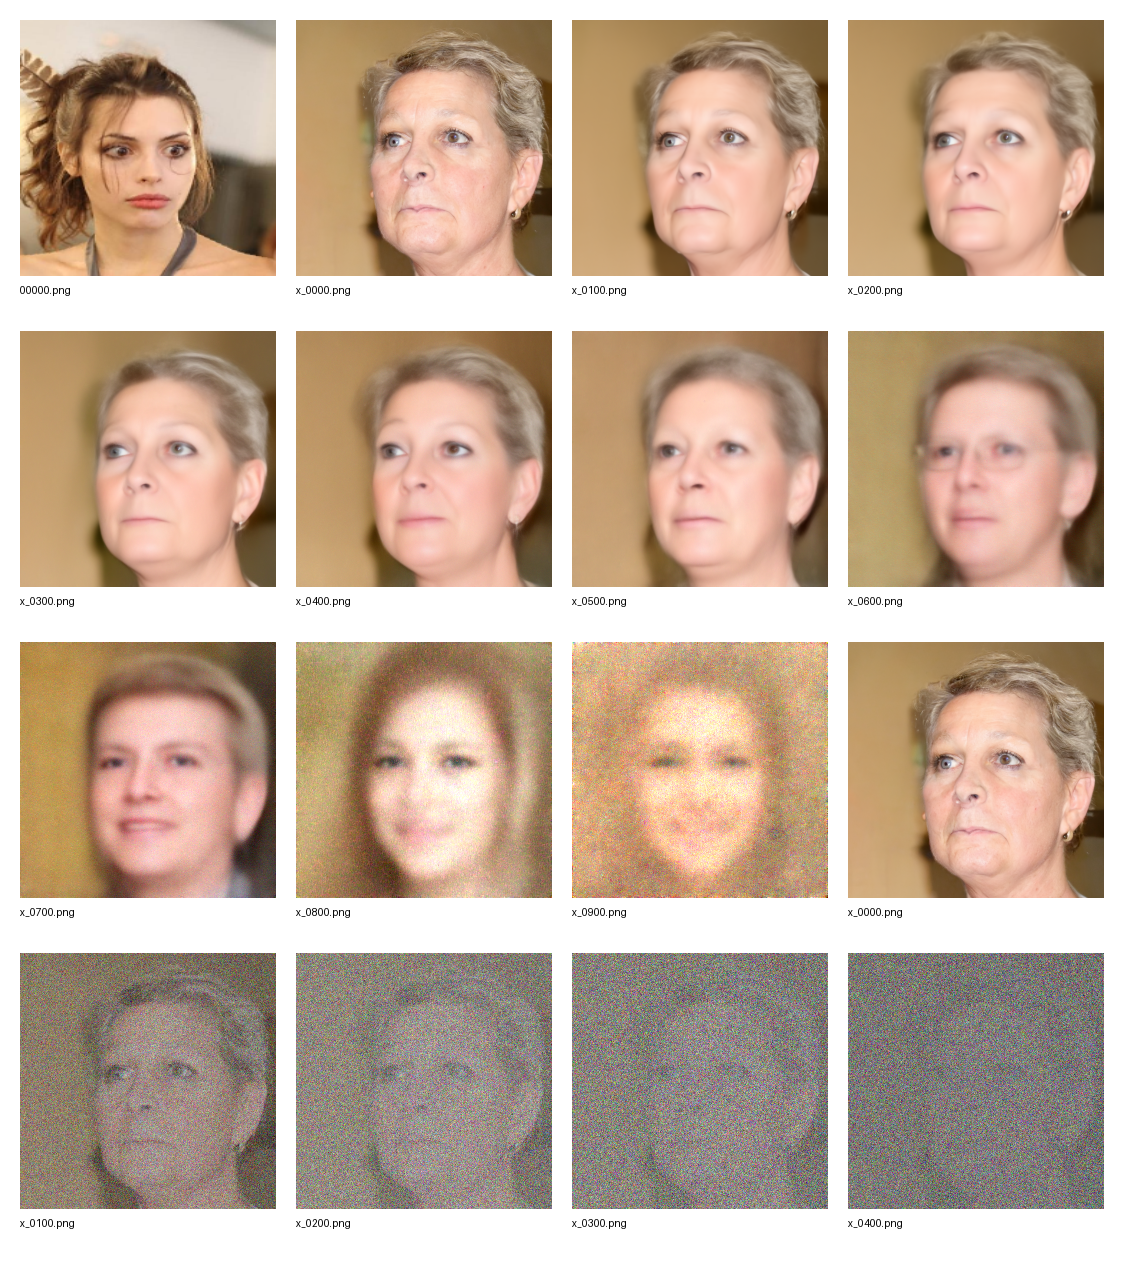

In [ ]:
# ============================================================
# CELL 15 — Contact sheet
# ============================================================

from PIL import Image, ImageDraw
import math

pngs = sorted(
    RUN_ROOT.rglob("*.png")
)

# Prefer final-looking files that are NOT intermediate x_t/x0
# files if such files exist.

preferred = [
    p for p in pngs
    if (
        "progress" not in str(p).lower()
        and p.name.startswith("sample")
    )
]

if not preferred:
    preferred = pngs

if not preferred:
    raise RuntimeError(
        "No PNG outputs were found."
    )

# ------------------------------------------------------------
# Keep at most 16 images in the contact sheet.
# ------------------------------------------------------------

selected = preferred[:16]

thumb_size = 256
margin = 20
label_height = 35

cols = 4
rows = math.ceil(
    len(selected) / cols
)

sheet_width = (
    cols * thumb_size
    + (cols + 1) * margin
)

sheet_height = (
    rows * (thumb_size + label_height)
    + (rows + 1) * margin
)

sheet = Image.new(
    "RGB",
    (
        sheet_width,
        sheet_height,
    ),
    "white",
)

draw = ImageDraw.Draw(sheet)

for i, path in enumerate(selected):

    img = Image.open(path).convert("RGB")

    img.thumbnail(
        (thumb_size, thumb_size)
    )

    x = (
        margin
        + (i % cols)
        * (thumb_size + margin)
    )

    y = (
        margin
        + (i // cols)
        * (
            thumb_size
            + label_height
            + margin
        )
    )

    sheet.paste(
        img,
        (x, y),
    )

    draw.text(
        (
            x,
            y + thumb_size + 8,
        ),
        path.name,
        fill="black",
    )

CONTACT_SHEET = (
    RUN_ROOT /
    "experiment_B_contact_sheet.png"
)

sheet.save(
    CONTACT_SHEET
)

print("Saved:")
print(CONTACT_SHEET)

display(sheet)

### Result

The contact sheet provides a qualitative view of the GSS-only trajectory. As timesteps progress (traversed backwards from 1000 to 0), the generated image becomes increasingly more face-like and less noisy. This is a sharp contrast to our previous unperturbed reproduction experiment which used `m_r=0.2`, where the reconstruction failed entirely, with the predicted images looking like patches of color, and even the final reconstructed image after a 1000 steps did not have any meaningful features pertaining to a human face. 

The results of this experiment (GSS with gradient guidance set to 0) and the previous experiment (Unconditional diffusion sampling) together determine that: The failure in reconstruction in the Unperturbed Reproduction experiment (using guidance coefficient `m_r=0.2`) was NOT caused by the diffusion model or an error in the GSS implementation.

The chances are that the leaked gradient produced by passing the target image through the victim model is unable to uniquely identify the image. The next diagnostic experiment will thus assess gradient identifiability.